In [1]:
import os
import netCDF4 as netcdf
import numpy as np
import sys
maindir = os.getcwd()
sys.path.append(maindir+"/src")

PATH = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP/Training-Ext/Amon/tas'

In [2]:
DIR_LIST = os.listdir(PATH)

dic_data = {}
dic_forced_response = {}

# how to center the data with respect to the monthly mean

# 1. calculate the monthly mean
# 2. subtract the monthly mean from the data
# 3. calculate the forced response by averaging over the time dimension

for idx_m, dir in enumerate(DIR_LIST):

    print(f'Processing {idx_m+1}/{len(DIR_LIST)}: {dir}')
    dir_path = os.path.join(PATH, dir)
    file_list = os.listdir(dir_path)

    dic_data[dir] = np.zeros((len(file_list), 2652, 72, 144), dtype=np.float32)
    dic_forced_response[dir] = np.zeros((len(file_list), 2652, 72, 144), dtype=np.float32)

    for idx_f, file in enumerate(file_list):
        print(f'  Processing {idx_f+1}/{len(file_list)}: {file}')
        file_path = os.path.join(dir_path, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # set variables
        time = np.array(netcdf_file.variables['time'][:])
        longitude = np.array(netcdf_file.variables['lon'][:])
        latitude = np.array(netcdf_file.variables['lat'][:])
        dic_data[dir][idx_f,:,:,:] = np.array(netcdf_file.variables['tas']) 
        for i in range(12):
            dic_data[dir][idx_f,np.arange(time.shape[0]) % 12 == i,:,:] = dic_data[dir][idx_f,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(dic_data[dir][idx_f, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

        # print(f'  Tas shape: {tas.shape}')
    dic_forced_response[dir][:,:,:,:] = np.nanmean(dic_data[dir], axis=0)
    


Processing 1/5: CESM2
  Processing 1/50: tas_mon_CESM2_historical_ssp370_r1251.013i1p1f1.188001-210012.nc
  Processing 2/50: tas_mon_CESM2_historical_ssp370_r1011.001i1p1f1.188001-210012.nc
  Processing 3/50: tas_mon_CESM2_historical_ssp370_r1251.015i1p1f1.188001-210012.nc
  Processing 4/50: tas_mon_CESM2_historical_ssp370_r1031.002i1p1f1.188001-210012.nc
  Processing 5/50: tas_mon_CESM2_historical_ssp370_r1251.014i1p1f1.188001-210012.nc
  Processing 6/50: tas_mon_CESM2_historical_ssp370_r1051.003i1p1f1.188001-210012.nc
  Processing 7/50: tas_mon_CESM2_historical_ssp370_r1251.016i1p1f1.188001-210012.nc
  Processing 8/50: tas_mon_CESM2_historical_ssp370_r1071.004i1p1f1.188001-210012.nc
  Processing 9/50: tas_mon_CESM2_historical_ssp370_r1251.017i1p1f1.188001-210012.nc
  Processing 10/50: tas_mon_CESM2_historical_ssp370_r1091.005i1p1f1.188001-210012.nc
  Processing 11/50: tas_mon_CESM2_historical_ssp370_r1251.018i1p1f1.188001-210012.nc
  Processing 12/50: tas_mon_CESM2_historical_ssp370_

In [3]:
# read the test data
PATH_EVAL = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/Evaluation-Tier1/'

DIR_LIST_TEST = os.listdir(PATH_EVAL)
data_test = np.zeros((10, 876, 72, 144), dtype=np.float32)

lst_test_name = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']

for idx_r, file in enumerate(DIR_LIST_TEST):

    if file.startswith('tas_') and file.endswith('.nc'):
        print(f'  Processing {idx_r+1}/{len(DIR_LIST_TEST)}: {file}')
        file_path = os.path.join(PATH_EVAL, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # set variables
        time = np.array(netcdf_file.variables['time'])
        longitude = np.array(netcdf_file.variables['lon'])
        latitude = np.array(netcdf_file.variables['lat'])

        if file[9] in lst_test_name:

            # find position of file[9] in lst_test_name
            idx_test = lst_test_name.index(file[9])
            print(f'  Found test data for {file[9]} at index {idx_test}')
            data_test[idx_test,:,:,:] = np.array(netcdf_file.variables['tas']) 
        
            for i in range(12):
                data_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] = data_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_test[idx_test, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

            print(f'  Tas shape: {data_test[idx_test,:,:,:].shape}')

  Processing 6/81: tas_mon_1F.195001-202212.nc
  Found test data for F at index 5
  Tas shape: (876, 72, 144)
  Processing 12/81: tas_mon_1C.195001-202212.nc
  Found test data for C at index 2
  Tas shape: (876, 72, 144)
  Processing 16/81: tas_mon_1H.195001-202212.nc
  Found test data for H at index 7
  Tas shape: (876, 72, 144)
  Processing 26/81: tas_mon_1G.195001-202212.nc
  Found test data for G at index 6
  Tas shape: (876, 72, 144)
  Processing 40/81: tas_mon_1D.195001-202212.nc
  Found test data for D at index 3
  Tas shape: (876, 72, 144)
  Processing 52/81: tas_mon_1J.195001-202212.nc
  Found test data for J at index 9
  Tas shape: (876, 72, 144)
  Processing 58/81: tas_mon_1A.195001-202212.nc
  Found test data for A at index 0
  Tas shape: (876, 72, 144)
  Processing 60/81: tas_mon_1E.195001-202212.nc
  Found test data for E at index 4
  Tas shape: (876, 72, 144)
  Processing 71/81: tas_mon_1B.195001-202212.nc
  Found test data for B at index 1
  Tas shape: (876, 72, 144)
  

In [4]:
# Read the ground truth data

PATH_GROUND_TRUTH = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/ensmeans-Tier1'

DIR_LIST_GROUND_TRUTH = os.listdir(PATH_GROUND_TRUTH)

data_ground_truth_test = np.zeros((10, 876, 72, 144), dtype=np.float32)

for idx_r, file in enumerate(DIR_LIST_GROUND_TRUTH):

    if file.__contains__('.tas.'):
        
        print(f'  Processing {idx_r+1}: {file}')

        # read the ground truth data
        file_path = os.path.join(PATH_GROUND_TRUTH, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # print(netcdf_file.variables)
        print(np.array(netcdf_file.variables['arr_EM']).shape)

        # set variables
        time = np.array(netcdf_file.variables['time'])
        longitude = np.array(netcdf_file.variables['lon'])
        latitude = np.array(netcdf_file.variables['lat'])

        if file[1] in lst_test_name:
            # find position of file[1] in lst_test_name
            idx_test = lst_test_name.index(file[1])
            print(f'  Found test data for {file[1]} at index {idx_test}')
            data_ground_truth_test[idx_test,:,:,:] = np.array(netcdf_file.variables['arr_EM'])

            for i in range(12):
                data_ground_truth_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] = data_ground_truth_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_ground_truth_test[idx_test, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

            print(f'  Tas shape: {data_ground_truth_test[idx_test,:,:,:].shape}')

  Processing 7: 1A.tas.EM.1950-2022.nc
(876, 72, 144)
  Found test data for A at index 0
  Tas shape: (876, 72, 144)
  Processing 15: 1B.tas.EM.1950-2022.nc
(876, 72, 144)
  Found test data for B at index 1
  Tas shape: (876, 72, 144)
  Processing 23: 1C.tas.EM.1950-2022.nc
(876, 72, 144)
  Found test data for C at index 2
  Tas shape: (876, 72, 144)
  Processing 31: 1D.tas.EM.1950-2022.nc
(876, 72, 144)
  Found test data for D at index 3
  Tas shape: (876, 72, 144)
  Processing 39: 1E.tas.EM.1950-2022.nc
(876, 72, 144)
  Found test data for E at index 4
  Tas shape: (876, 72, 144)
  Processing 47: 1F.tas.EM.1950-2022.nc
(876, 72, 144)
  Found test data for F at index 5
  Tas shape: (876, 72, 144)
  Processing 55: 1G.tas.EM.1950-2022.nc
(876, 72, 144)
  Found test data for G at index 6
  Tas shape: (876, 72, 144)
  Processing 63: 1H.tas.EM.1950-2022.nc
(876, 72, 144)
  Found test data for H at index 7
  Tas shape: (876, 72, 144)
  Processing 71: 1J.tas.EM.1950-2022.nc
(876, 72, 144)
  

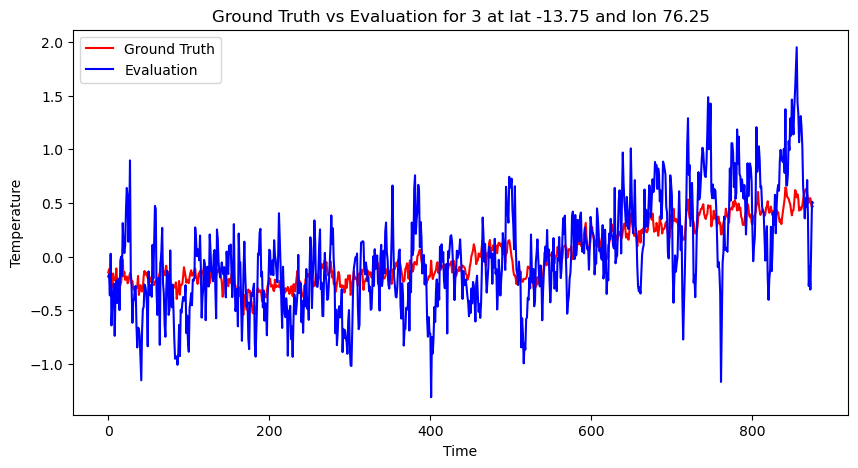

In [5]:
# check if the data is correct by plotting the ensemble mean and the evaluation data on the same plot
import matplotlib.pyplot as plt

idx_run = 3
idx_lat = 30
idx_lon = 30

x_tmp = data_ground_truth_test[idx_run,:,idx_lat,idx_lon]
y_tmp = data_test[idx_run,:,idx_lat,idx_lon]

plt.figure(figsize=(10, 5))
plt.plot(x_tmp, label='Ground Truth', color='red')
plt.plot(y_tmp, label='Evaluation', color='blue')
plt.title(f'Ground Truth vs Evaluation for {idx_run} at lat {latitude[idx_lat]} and lon {longitude[idx_lon]}')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.show()

In [6]:
import torch

def normalize_data(data, means, vars):
    """Normalize the data with respect to the monthly mean and the variance of the anomaly.
       Args:
           data: numpy array of shape (runs, time steps, latitude, longitude)
           means: numpy array of shape (runs, latitude, longitude)
           vars: numpy array of shape (runs, latitude, longitude)
       Return:
           normalized_data: numpy array of shape (runs, time steps, latitude, longitude)
    """
    normalized_data = {}
    for idx,key in enumerate(data.keys()):
        normalized_data[key] = (data[key] - means[key]) / np.sqrt(vars[key])
    return normalized_data

def merge_training_data(x,y,dtype=torch.float32):
    """Concatenate training sets for all models except model m. This enables to create the big matrices X and Y.
        Unnormalized data.
       Args:

       Return:
    """
    ################ We construct X, Y in R^{grid x runs*time steps}

    # Concatenate all models to build the matrix X
    
    for idx_m,m in enumerate(x.keys()):
        
        if idx_m ==0:

            x_train = torch.from_numpy(x[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0])/torch.sqrt(torch.tensor(x[m].shape[0]))
            y_train = torch.from_numpy(y[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0])/torch.sqrt(torch.tensor(x[m].shape[0]))


        else:
            x_train = torch.cat([x_train, torch.from_numpy(x[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0]) /torch.sqrt(torch.tensor(x[m].shape[0]))],dim=0)
            y_train = torch.cat([y_train, torch.from_numpy(y[m]).to(torch.float32).reshape(-1,longitude.shape[0]*latitude.shape[0]) /torch.sqrt(torch.tensor(x[m].shape[0]))],dim=0)

        print(f'  x_train shape: {x_train.shape}')
    return x_train, y_train


def reshape_training_data(x,y,dtype=torch.float32):
    """Concatenate training sets for all models except model m. This enables to create the big matrices X and Y.
        Unnormalized data.
       Args:

       Return:
    """
    ################ We construct X, Y in R^{grid x runs*time steps}

    # Concatenate all models to build the matrix X
    x_train = {}
    y_train = {}
    
    for idx_m,m in enumerate(x.keys()):
        
        x_train[m] = torch.from_numpy(x[m]).to(torch.float32).reshape(x[m].shape[0],x[m].shape[1],longitude.shape[0]*latitude.shape[0])
        y_train[m] = torch.from_numpy(y[m]).to(torch.float32).reshape(x[m].shape[0],x[m].shape[1],longitude.shape[0]*latitude.shape[0])
        print(f'  x_train shape: {x_train[m].shape}')
        print(f'  y_train shape: {y_train[m].shape}')
    return x_train, y_train

In [7]:
def yearly_average(x, months_per_year=12):
    """
    Compute the yearly average of a time series.
    Args:
        data: numpy array of shape (time, ...)
        months_per_year: int, number of months in a year (default: 12)
    Returns:
        numpy array of shape (years, ...)
    """
    n_years = x.shape[1] // months_per_year
    data_reshaped = x.reshape(x.shape[0],n_years, months_per_year, x.shape[2],x.shape[3])
    return data_reshaped.mean(axis=2)


# Compute the yearly average for each key in the dictionary
def compute_yearly_average(data, months_per_year=12):
    """
    Compute the yearly average of a dictionary of numpy arrays.
    Args:
        data: dictionary of numpy arrays
        months_per_year: int, number of months in a year (default: 12)
    Returns:
        dictionary of numpy arrays with yearly averages
    """
    yearly_data = {}
    for key, m in enumerate(data.keys()):
        yearly_data[m] = yearly_average(data[m], months_per_year)

    return yearly_data

In [8]:
# compute training set and test set
x_train, y_train  = merge_training_data(dic_data,dic_forced_response,dtype=torch.float32)
x, y = reshape_training_data(dic_data,dic_forced_response,dtype=torch.float32)

  x_train shape: torch.Size([132600, 10368])
  x_train shape: torch.Size([198900, 10368])
  x_train shape: torch.Size([278460, 10368])
  x_train shape: torch.Size([411060, 10368])
  x_train shape: torch.Size([490620, 10368])
  x_train shape: torch.Size([50, 2652, 10368])
  y_train shape: torch.Size([50, 2652, 10368])
  x_train shape: torch.Size([25, 2652, 10368])
  y_train shape: torch.Size([25, 2652, 10368])
  x_train shape: torch.Size([30, 2652, 10368])
  y_train shape: torch.Size([30, 2652, 10368])
  x_train shape: torch.Size([50, 2652, 10368])
  y_train shape: torch.Size([50, 2652, 10368])
  x_train shape: torch.Size([30, 2652, 10368])
  y_train shape: torch.Size([30, 2652, 10368])


In [9]:
# Read the estimates of the other methods
# read the test data
PATH_TEST = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/ForceSMIP-estimates-Tier1'

DIR_LIST_TEST = os.listdir(PATH_TEST)
data_estimates = np.zeros((30,10, 876, 72, 144), dtype=np.float32)

for idx_r, file in enumerate(DIR_LIST_TEST):

    if file.startswith('tas_'):

        # read the test data
        print(f'  Processing {idx_r+1}/{len(DIR_LIST_TEST)}: {file}')
        file_path = os.path.join(PATH_TEST, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')


        # set variables
        time = np.array(netcdf_file.variables['time'])
        longitude = np.array(netcdf_file.variables['lon'])
        latitude = np.array(netcdf_file.variables['lat'])
        if file[5] in lst_test_name:
            # find position of file[1] in lst_test_name
            idx_test = lst_test_name.index(file[5])
            print(f'  Found test data for {file[5]} at index {idx_test}')
            data_estimates[:,idx_test,:,:,:] = np.array(netcdf_file.variables['forced_component']) 

        print(f'  Tas shape: {data_estimates[:,idx_test,:,:,:].shape}')

lst_to_center = [8,9,14,24]

# center the methods that are not centered
for idx_m in lst_to_center:
    print(f'Centering data for method {idx_m}')
    for i in range(12):
        data_estimates[idx_m,:,np.arange(time.shape[0]) % 12 == i,:,:] = data_estimates[idx_m,:,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_estimates[idx_m,:, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)


  Processing 51/80: tas_1A_1950_2022.nc
  Found test data for A at index 0
  Tas shape: (30, 876, 72, 144)
  Processing 52/80: tas_1B_1950_2022.nc
  Found test data for B at index 1
  Tas shape: (30, 876, 72, 144)
  Processing 53/80: tas_1C_1950_2022.nc
  Found test data for C at index 2
  Tas shape: (30, 876, 72, 144)
  Processing 54/80: tas_1D_1950_2022.nc
  Found test data for D at index 3
  Tas shape: (30, 876, 72, 144)
  Processing 55/80: tas_1E_1950_2022.nc
  Found test data for E at index 4
  Tas shape: (30, 876, 72, 144)
  Processing 56/80: tas_1F_1950_2022.nc
  Found test data for F at index 5
  Tas shape: (30, 876, 72, 144)
  Processing 57/80: tas_1G_1950_2022.nc
  Found test data for G at index 6
  Tas shape: (30, 876, 72, 144)
  Processing 58/80: tas_1H_1950_2022.nc
  Found test data for H at index 7
  Tas shape: (30, 876, 72, 144)
  Processing 59/80: tas_1I_1950_2022.nc
  Found test data for I at index 8
  Tas shape: (30, 876, 72, 144)
  Processing 60/80: tas_1J_1950_2022.

In [10]:
# compute mse of the other estimates
mse_estimates = np.zeros((data_estimates.shape[0],data_estimates.shape[1]))

for idx_r in range(data_estimates.shape[0]):
    mse_estimates[idx_r,:] = np.sqrt(np.mean((data_estimates[idx_r,:,:,:,:] - data_ground_truth_test) ** 2,axis=(1,2,3))) 
    print(f'  MSE estimates: {mse_estimates[idx_r,:]}')

mse_estimates[:,8] = 0.0

  MSE estimates: [0.49550778 0.51100057 0.67596477 0.84101903 0.48415652 0.47930476
 0.61143172 0.43098748 0.64807928 0.51178229]
  MSE estimates: [0.51639372 0.5460459  0.65299219 0.7674492  0.49941075 0.50957346
 0.57887173 0.46936822 0.68619871 0.59348494]
  MSE estimates: [0.49182796 0.5012449  0.58460832 0.87728935 0.48170397 0.48428568
 0.55289179 0.44784209 0.7546466  0.57025641]
  MSE estimates: [0.43085137 0.56283027 0.78117096 0.44237232 0.5036909  0.4146412
 0.49771696 0.31438255 0.44269887 0.48009971]
  MSE estimates: [0.42836311 0.43215752 0.62536472 0.59834325 0.44574437 0.43019038
 0.52151704 0.38851166 0.53218716 0.47624314]
  MSE estimates: [0.36044395 0.38175088 0.56761026 0.45852318 0.4024646  0.35533607
 0.47676918 0.31087133 0.44567934 0.43520856]
  MSE estimates: [0.38899282 0.41481045 0.6190955  0.73331398 0.422548   0.38153708
 0.50368208 0.33451095 0.55205292 0.43823734]
  MSE estimates: [0.49169007 0.50437868 0.69514912 0.77526796 0.50779128 0.50623846
 0.5940

In [11]:
# Train the model on the yearly data
dic_data_yearly = compute_yearly_average(dic_data, months_per_year=12)
dic_forced_response_yearly = compute_yearly_average(dic_forced_response, months_per_year=12)

x_test_yearly = yearly_average(data_test, months_per_year=12)
y_test_yearly = yearly_average(data_ground_truth_test, months_per_year=12)

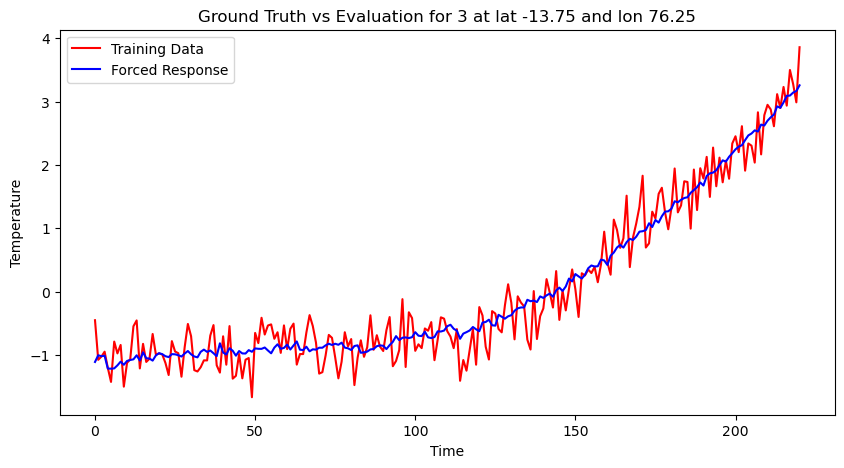

In [12]:
# plot time series in a single grid cell
idx_lat = 30
idx_lon = 30
plt.figure(figsize=(10, 5))
plt.plot(dic_data_yearly['CESM2'][0,:,idx_lat,idx_lon], label='Training Data', color='red')
plt.plot(dic_forced_response_yearly['CESM2'][0,:,idx_lat,idx_lon], label='Forced Response', color='blue')
plt.title(f'Ground Truth vs Evaluation for {idx_run} at lat {latitude[idx_lat]} and lon {longitude[idx_lon]}')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.show()

In [13]:
# compute the variance of anomaly per climate model and standardize
means_yearly = {}
vars_yearly = {}
vars = {}
means = {}

# for each model, compute the variance of the anomaly
for dir in DIR_LIST:
    print(f'Computing variance for {dir}')
    # means_yearly[dir] = np.nanmean(dic_data_yearly[dir], axis=0)
    means_yearly[dir] =  np.zeros((dic_data_yearly[dir].shape[1], dic_data_yearly[dir].shape[2], dic_data_yearly[dir].shape[3]), dtype=np.float32)
    vars_yearly[dir] = np.nanvar(dic_data_yearly[dir], axis=0)
    vars[dir] = np.nanvar(dic_data[dir], axis=0)
    means[dir] = np.zeros((dic_data[dir].shape[1], dic_data[dir].shape[2], dic_data[dir].shape[3]), dtype=np.float32)


# normalize the data
# dic_data_tmp = normalize_data(dic_data, means, vars)
# dic_forced_response_tmp = normalize_data(dic_forced_response, means, vars)

# dic_data_yearly_tmp = normalize_data(dic_data_yearly, means_yearly, vars_yearly)
# dic_forced_response_yearly_tmp= normalize_data(dic_forced_response_yearly, means_yearly, vars_yearly)

Computing variance for CESM2
Computing variance for CanESM5
Computing variance for MIROC-ES2L
Computing variance for MIROC6
Computing variance for MPI-ESM1-2-LR


In [14]:
# train the models on yearly data
# compute training set and test set

x_train_yearly, y_train_yearly  = merge_training_data(dic_data_yearly,dic_forced_response_yearly,dtype=torch.float32)
# x_train_yearly_tmp, y_train_yearly_tmp  = merge_training_data(dic_data_yearly_tmp,dic_forced_response_yearly_tmp,dtype=torch.float32)

x_yearly, y_yearly = reshape_training_data(dic_data_yearly,dic_forced_response_yearly,dtype=torch.float32)

# stack all the items in x_yearly and y_yearly
x_yearly_stacked = 0
y_yearly_stacked = 0

for idx,key in enumerate(x_yearly.keys()):

    if idx == 0:
        x_yearly_stacked = x_yearly[key]
        y_yearly_stacked = y_yearly[key]
    else:
        x_yearly_stacked = torch.cat([x_yearly_stacked, x_yearly[key]], dim=0)
        y_yearly_stacked = torch.cat([y_yearly_stacked, y_yearly[key]], dim=0)
print(f'x_yearly_stacked shape: {x_yearly_stacked.shape}')
print(f'y_yearly_stacked shape: {y_yearly_stacked.shape}')

  x_train shape: torch.Size([11050, 10368])
  x_train shape: torch.Size([16575, 10368])
  x_train shape: torch.Size([23205, 10368])
  x_train shape: torch.Size([34255, 10368])
  x_train shape: torch.Size([40885, 10368])
  x_train shape: torch.Size([50, 221, 10368])
  y_train shape: torch.Size([50, 221, 10368])
  x_train shape: torch.Size([25, 221, 10368])
  y_train shape: torch.Size([25, 221, 10368])
  x_train shape: torch.Size([30, 221, 10368])
  y_train shape: torch.Size([30, 221, 10368])
  x_train shape: torch.Size([50, 221, 10368])
  y_train shape: torch.Size([50, 221, 10368])
  x_train shape: torch.Size([30, 221, 10368])
  y_train shape: torch.Size([30, 221, 10368])
x_yearly_stacked shape: torch.Size([185, 221, 10368])
y_yearly_stacked shape: torch.Size([185, 221, 10368])


In [ ]:
# Diffusion model for a subset of the data

import torch
import torch.nn as nn
import torch.nn.functional as F

# --- Simple Denoising Network (MLP) ---
class SimpleDenoiser(nn.Module):
    def __init__(self, d, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d + 1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, d)
        )

    def forward(self, x, t):
        # x: (batch, d), t: (batch, 1)
        xt = torch.cat([x, t], dim=-1)
        return self.net(xt)

# --- Diffusion Model ---
class DiffusionModel(nn.Module):
    def __init__(self, d, timesteps=1000):
        super().__init__()
        self.timesteps = timesteps
        self.denoiser = SimpleDenoiser(d)
        # Linear beta schedule
        self.register_buffer('betas', torch.linspace(1e-4, 0.02, timesteps))
        alphas = 1. - self.betas
        self.register_buffer('alphas_cumprod', torch.cumprod(alphas, dim=0))

    def q_sample(self, x0, t, noise=None):
        # x0: (batch, d), t: (batch,)
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_alphas_cumprod = self.alphas_cumprod[t].sqrt().unsqueeze(-1)
        sqrt_one_minus = (1 - self.alphas_cumprod[t]).sqrt().unsqueeze(-1)
        return sqrt_alphas_cumprod * x0 + sqrt_one_minus * noise

    def forward(self, x0, noise_target):
        # x0: (batch, T, d)
        B, T, d = x0.shape
        t = torch.randint(0, self.timesteps, (B, T), device=x0.device)
        noise = torch.randn_like(x0)

        # Sample noisy x
        x_noisy = self.q_sample(x0.view(-1, d), t.view(-1), noise=noise.view(-1, d))

        # Predict noise
        pred_noise = self.denoiser(x_noisy, t.view(-1, 1))

        # Compute loss
        loss = F.mse_loss(pred_noise, noise_target.view(-1, d))

        return loss

    @torch.no_grad()
    def sample(self, shape, device=None):
        # shape: (batch, T, d)
        B, T, d = shape
        x = torch.randn(B * T, d, device=device)
        for t in reversed(range(self.timesteps)):
            t_tensor = torch.full((B * T, 1), t, device=x.device, dtype=torch.long)
            pred_noise = self.denoiser(x, t_tensor)
            alpha = self.alphas_cumprod[t]
            beta = self.betas[t]
            x0_pred = (x - (1 - alpha).sqrt() * pred_noise) / alpha.sqrt()
            if t > 0:
                noise = torch.randn_like(x)
                x = alpha.sqrt() * x0_pred + (1 - alpha).sqrt() * noise
            else:
                x = x0_pred
        return x.view(B, T, d)

# --- Example usage ---
if __name__ == "__main__":
    # Example: batch of 8, T=10, d=64 (e.g. 8 time series of 10 images, each 8x8 flattened)
    B, T, d = 8, 10, 64
    model = DiffusionModel(d)
    x = torch.randn(B, T, d)
    x_target = torch.randn(B, T, d)
    y_target = torch.randn(B, T, d)
    noise_target =  torch.sqrt((x_target -y_target) ** 2)


    loss = model(x,noise_target)
    print("Loss:", loss.item())

    # Sampling
    with torch.no_grad():
        samples = model.sample((B, T, d), device=x.device)
        print("Sampled shape:", samples.shape)

torch.Size([8, 10, 64])
pred_noise shape: torch.Size([80, 64]), noise_target shape: torch.Size([8, 10, 64])
Loss: 69.03191375732422
Sampled shape: torch.Size([8, 10, 64])


In [48]:
from torch.utils.data import DataLoader, TensorDataset

# Suppose x_yearly_stacked is your (N, T, d) training data
batch_size = 16
train_loader = DataLoader(TensorDataset(x_yearly_stacked,y_yearly_stacked), batch_size=batch_size, shuffle=True)


d = x_yearly_stacked.shape[2]
diffusion_model = DiffusionModel(d)
optimizer = torch.optim.Adam(diffusion_model.parameters(), lr=1e-3)
epochs = 20

for epoch in range(epochs):
    diffusion_model.train()
    total_loss = 0
    for (batch_x,batch_y) in train_loader:
        # batch_x = batch_x.to(device)
        target_noise =  torch.sqrt((batch_x - batch_y) ** 2)
        loss = diffusion_model(batch_x,batch_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

pred_noise shape: torch.Size([3536, 10368]), noise_target shape: torch.Size([16, 221, 10368])
pred_noise shape: torch.Size([3536, 10368]), noise_target shape: torch.Size([16, 221, 10368])
pred_noise shape: torch.Size([3536, 10368]), noise_target shape: torch.Size([16, 221, 10368])
pred_noise shape: torch.Size([3536, 10368]), noise_target shape: torch.Size([16, 221, 10368])
pred_noise shape: torch.Size([3536, 10368]), noise_target shape: torch.Size([16, 221, 10368])
pred_noise shape: torch.Size([3536, 10368]), noise_target shape: torch.Size([16, 221, 10368])
pred_noise shape: torch.Size([3536, 10368]), noise_target shape: torch.Size([16, 221, 10368])
pred_noise shape: torch.Size([3536, 10368]), noise_target shape: torch.Size([16, 221, 10368])
pred_noise shape: torch.Size([3536, 10368]), noise_target shape: torch.Size([16, 221, 10368])
pred_noise shape: torch.Size([3536, 10368]), noise_target shape: torch.Size([16, 221, 10368])
pred_noise shape: torch.Size([3536, 10368]), noise_target sh

In [50]:
# compute prediction for the test set
with torch.no_grad():
    diffusion_model.eval()
    # x_test_yearly_stacked = x_test_yearly).to(torch.float32).reshape(x_test_yearly.shape[0],x_test_yearly.shape[1],longitude.shape[0]*latitude.shape[0])
    y_pred = diffusion_model.sample((x_test_yearly.shape[0], x_test_yearly.shape[1], d), device=x_test_yearly_stacked.device)
    # y_pred = y_pred.reshape(y_pred.shape[0],y_pred.shape[1],latitude.shape[0],longitude.shape[0]).detach().numpy()

In [52]:
# compute the mean squared error
rmse_diffusion = torch.sqrt(torch.mean((y_pred - y_test_yearly) ** 2, axis=(0,1))).detach().numpy()
print(f'RMSE GP: {rmse_diffusion}')

RMSE GP: [ 67008.17  213338.    426782.6   ... 305037.1    54717.082 106747.984]


In [53]:
y_pred

tensor([[[ 8.9109e-01, -1.9697e+03, -1.4176e+03,  ..., -4.7066e+03,
           2.0399e+03, -1.4334e+02],
         [-3.8034e+04, -8.7236e+04,  6.9278e+04,  ..., -6.5583e+04,
           2.0332e+04, -6.5357e+04],
         [ 3.3661e+03,  1.8369e+03, -6.2675e+03,  ..., -4.1388e+03,
           3.2562e+03, -5.0497e+03],
         ...,
         [-5.0145e+04, -1.6480e+05,  2.2724e+05,  ..., -1.8330e+05,
           1.2112e+05, -1.4283e+05],
         [-1.0716e+03, -2.1844e+03,  2.3759e+03,  ..., -3.1388e+03,
          -1.4531e+02, -1.3874e+03],
         [-5.1265e+04, -1.7803e+05,  2.9713e+05,  ..., -1.5372e+05,
           9.4284e+04, -1.1977e+05]],

        [[-1.8361e+04, -6.6256e+04,  1.0337e+05,  ..., -6.6703e+04,
           3.5957e+04, -4.9017e+04],
         [ 2.0440e+04, -1.5659e+05,  1.0423e+05,  ..., -2.7252e+05,
           1.1542e+03, -1.3614e+05],
         [ 3.1667e+03, -3.0377e+03, -1.7592e+03,  ...,  2.2534e+02,
           9.8894e+03,  1.4793e+04],
         ...,
         [-3.8534e+04, -1

In [32]:
y_pred

tensor([[[ 1.1876e+03, -1.2593e+02,  4.3647e+02,  ...,  1.0730e+02,
           6.7578e+02,  3.4774e+02],
         [-8.5465e+01,  1.3363e+01,  7.7503e+01,  ..., -9.2082e+01,
           1.1761e+02,  7.3059e+01],
         [-5.0164e+01,  1.8839e+01,  2.7843e+01,  ...,  9.3698e+00,
           1.7688e+01,  2.1238e+01],
         ...,
         [ 1.3131e+04,  3.4217e+03,  2.7180e+03,  ...,  3.3245e+03,
           1.4009e+03,  7.1179e+03],
         [ 8.7069e+01,  1.7882e+01,  5.4821e+01,  ...,  3.2679e+01,
          -1.5391e+01, -2.7144e+01],
         [ 3.8573e+01,  1.3140e+02,  2.4376e+01,  ...,  3.7091e+00,
          -4.6737e+01, -4.3280e+01]],

        [[ 9.9435e+01,  2.0291e+01, -9.0438e+00,  ...,  8.4892e+01,
          -2.6698e+01,  7.0182e+01],
         [ 6.2873e+02,  2.9931e+02, -4.1578e+02,  ...,  1.4842e+03,
          -8.4225e+02, -1.8510e+02],
         [ 6.0574e+00,  2.0757e+01,  9.3650e+01,  ..., -4.3160e+01,
           7.5866e+01,  1.4699e+01],
         ...,
         [ 6.5247e+02,  5

In [15]:
# Use MPS / Cuda or CPU if none of the options are available
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
np.random.seed(42)

Using device: cpu


In [40]:
# Create the DataLoader with x_st
from torch.utils.data import DataLoader, TensorDataset

# Create a TensorDataset
train_dataset = TensorDataset(x_yearly_stacked, y_yearly_stacked)

# Create a DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

from trend_vae import Trend_Vae

# Set VAE parameters
hidden_dim = 128 # Increased for better representation
feat_dim = x_yearly_stacked.shape[2]
latent_dim = 64 # Intermediate layer size
z_dim = 5 # Actual latent space dimension
trend_poly = 2
# seq_len, _ = sample
seq_len = x_yearly_stacked.shape[1]  # Sequence length from the input data
print(f"The sequence length is {seq_len}")
# beta = 0.001      # Weight for KL divergence term -- not used in this version

# Create the model
vae_model = Trend_Vae(
    seq_len=seq_len,
    feat_dim=feat_dim,
    hidden_dim=hidden_dim,
    latent_dim=latent_dim,
    z_dim=z_dim,
    trend_poly=trend_poly,
    use_residual_conn=True,
    device=device,
).to(device)

# Print model summary
print("\nTrend VAE Model Architecture:")
print(vae_model)
print(f"\nTotal parameters: {sum(p.numel() for p in vae_model.parameters() if p.requires_grad):,}")


The sequence length is 221

Trend VAE Model Architecture:
Trend_Vae(
  (encoder): TrendVAEEncoder(
    (encoder): Sequential(
      (0): Conv1d(10368, 128, kernel_size=(3,), stride=(2,), padding=(1,))
      (1): ReLU()
      (2): Conv1d(128, 64, kernel_size=(3,), stride=(2,), padding=(1,))
      (3): ReLU()
      (4): Flatten(start_dim=1, end_dim=-1)
    )
    (z_mean): Linear(in_features=3584, out_features=5, bias=True)
    (z_log_var): Linear(in_features=3584, out_features=5, bias=True)
  )
  (decoder): TrendVAEDecoder(
    (level_model): LevelModel(
      (level_dense1): Linear(in_features=5, out_features=10368, bias=True)
      (level_dense2): Linear(in_features=10368, out_features=10368, bias=True)
      (relu): ReLU()
    )
    (trend_layer): TrendLayer(
      (trend_dense1): Linear(in_features=5, out_features=20736, bias=True)
      (trend_dense2): Linear(in_features=20736, out_features=20736, bias=True)
    )
    (residual_conn): ResidualConnection(
      (fc): Linear(in_featur

In [17]:
from trend_vae import train_vae
# Train the VAE
epochs = 200
losses = []

optimizer = torch.optim.Adam(vae_model.parameters(), lr=3e-4) # Weight decay is not used in this version (was weight_decay=1e-5)

losses = train_vae(vae_model, train_loader, optimizer, epochs=epochs, device=device)


  0%|          | 1/200 [00:06<21:59,  6.63s/it]

Epoch 1, Loss: 141712103.4378


  6%|▌         | 11/200 [01:11<20:14,  6.43s/it]

Epoch 11, Loss: 9089957.7081


 10%|█         | 21/200 [02:15<19:11,  6.44s/it]

...

 90%|█████████ | 181/200 [19:26<02:02,  6.45s/it]

Epoch 181, Loss: 596498.2486


 96%|█████████▌| 191/200 [20:30<00:58,  6.46s/it]

Epoch 191, Loss: 570777.2757


100%|██████████| 200/200 [21:29<00:00,  6.45s/it]


In [19]:
### Training dates 
years_train = np.arange(2100 - 1880 +1)

# year index to a scalar in [0,1]
years_train_idx_feature = years_train  # normalize to [0,1] range

# get index of years 1950 - 2022
years_test = years_train[(years_train >= 1950-1880) & (years_train <= 2022-1880)]
years_test_idx_feature =  years_test


print("Training years:", years_train_idx_feature)
print("Test years:", years_test_idx_feature)

Training years: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220]
Test years: [ 70  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87
 

In [43]:
x_test_yearly_tmp = torch.zeros((x_test_yearly.shape[0],years_train_idx_feature.shape[0], longitude.shape[0]*latitude.shape[0]), dtype=torch.float32)
x_test_yearly_tmp[:,years_test_idx_feature,:] = torch.from_numpy(x_test_yearly).reshape(x_test_yearly.shape[0], x_test_yearly.shape[1], longitude.shape[0]*latitude.shape[0])

In [44]:
train_only_idx = list(set(years_train_idx_feature) - set(years_test_idx_feature))

In [ ]:
x_test_yearly_tmp[:,train_only_idx,:] = torch.nanmean(x_yearly_stacked[:,train_only_idx,:], dim=0)
# x_test_yearly_tmp[:,train_only_idx,:] = torch.nanmean(x_yearly_stacked[:,train_only_idx,:], dim=0)


In [46]:
# evaluate the vae on test data
vae_model.eval()
with torch.no_grad():
    # Move the test data to the same device as the model
    x_test_yearly_tmp = x_test_yearly_tmp.to(device)
    
    # Get the VAE estimates
    y_pred_vae = vae_model(x_test_yearly_tmp)

# # compute mse of the vae estimates
# mse_estimates_vae = np.zeros((data_estimates.shape[0],data_estimates.shape[1]))
# for idx_r in range(data_estimates.shape[0]):
#     mse_estimates_vae[idx_r,:] = np.sqrt(np.mean((data_estimates[idx_r,:,:,:].cpu().numpy() - data_ground_truth_test) ** 2,axis=(1,2,3))) 
#     print(f'  MSE estimates: {mse_estimates_vae[idx_r,:]}')

In [49]:
y_pred_vae_tmp = y_pred_vae[0]

In [56]:
torch.mean((y_pred_vae_tmp[:,years_test_idx_feature,:] - y_test_yearly.reshape(10,73,longitude.shape[0]*latitude.shape[0])) ** 2, axis=(1,2))

tensor([0.4660, 0.9307, 1.1628, 1.2127, 0.6389, 0.4649, 1.1224, 0.4251, 0.5544,
        0.5859])

In [38]:
# vae_model.eval()

# with torch.no_grad():
#     # Forward pass through the VAE
#     # print(torch.tensor(x_test_yearly_tmp[0,:,:]).unsqueeze(0).shape)
#     U = torch.rand(1,73,x_yearly_stacked.shape[2])  # Random input for the VAE
#     reconstructed, mu, log_var = vae_model(U)  # Output shape: (1, 165, 6523)
#     prediction = reconstructed.squeeze(0).cpu().numpy()  # Remove batch dimension, shape: (165, 6523)